# Prep PDAC: CyTOF7-style normalization

This notebook follows the normalization flow used in `CyTOF7-NewNorm.ipynb`:
1. Gate cells with low core histones (`H3.3`, `H3`, `H4`).
2. Apply arcsinh transform with cofactor 5.
3. Estimate technical factor from core histones and correct intracellular markers **separately for each sample**.
4. Save normalized data as an `.h5ad` file in `../data/`.


In [11]:
import os
import sys
import types
from pathlib import Path

import anndata as ad
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Writable cache dirs (helps in restricted environments)
os.environ.setdefault('MPLCONFIGDIR', str((Path('../tmp/mplconfig')).resolve()))
os.environ.setdefault('NUMBA_CACHE_DIR', str((Path('../tmp/numba_cache')).resolve()))

# Match CyTOF7-NewNorm imports
sys.path.append('/Users/ronguy/Dropbox/Work/CyTOF/Code')
from CyTOFHelper import GetMarkers

try:
    from cytof_transform import (
        CytofTransformConfig,
        cytof_transform_global,
        plot_tech_factor_qc,
        plot_marker_correlations_qc,
    )
except RuntimeError as exc:
    # Fallback for environments where importing umap triggers numba cache errors.
    if "cannot cache function 'rdist'" not in str(exc):
        raise
    sys.modules.pop('cytof_transform', None)
    sys.modules.setdefault('umap', types.ModuleType('umap'))
    from cytof_transform import (
        CytofTransformConfig,
        cytof_transform_global,
        plot_tech_factor_qc,
        plot_marker_correlations_qc,
    )

hKWD = {'element': 'step', 'fill': False, 'stat': 'density'}
%matplotlib inline

In [12]:
INPUT_CSV = Path('../data/All.csv')
OUTPUT_H5AD = Path('../data/PDAC_normalized.h5ad')

DF = pd.read_csv(INPUT_CSV)
print('Loaded:', INPUT_CSV.resolve())
print('Shape :', DF.shape)

# Use the same replacement map pattern as in CyTOF7-NewNorm
Rep=dict(pd.read_excel('/Users/ronguy/Dropbox/Work/CyTOF/Mapping.xlsx').iloc[:,:].values)
Rep['H3K27Ac'] = 'H3K27ac'
DF = DF.rename(columns=Rep)

metadata_cols = ['cell_id', 'sample', 'Treatment']
marker_cols = [c for c in DF.columns if c not in metadata_cols]

print('Markers:', len(marker_cols))
print('Samples:', sorted(DF['sample'].astype(str).unique().tolist()))


Loaded: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/data/All.csv
Shape : (76730, 44)
Markers: 41
Samples: ['66', '68', '71']


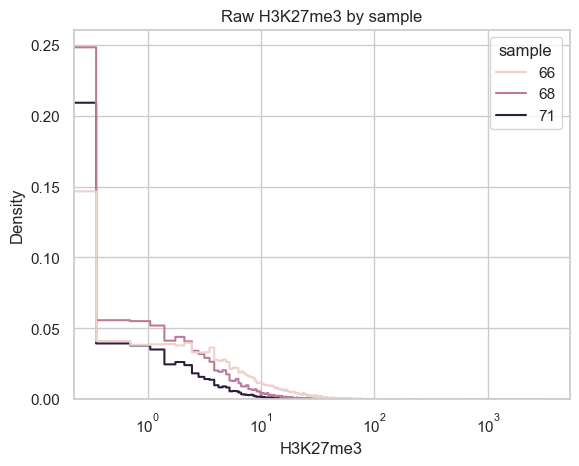

In [13]:
# Raw QC (before gating/normalization)
sns.histplot(
    data=DF,
    x='H3K27me3',
    hue='sample',
    stat='density',
    fill=False,
    element='step'
)
plt.title('Raw H3K27me3 by sample')
plt.xscale('log')
plt.show()


In [14]:
# Step 1: Gate on core histones (same as CyTOF7-NewNorm)
GateColumns = ['H3.3', 'H4', ]

def Gate(data, name='PDAC'):
    ddf = data.copy()
    print(name)
    print('Initial   ', len(ddf))
    ddf = ddf[(ddf[GateColumns] > 5).all(axis=1)]
    print('Core Gate ', len(ddf))
    # ddf = ddf[(ddf < np.quantile(ddf, 0.9999, axis=0)).all(axis=1)]
    print('Outlier Gate ', len(ddf))
    return ddf

DF_gated = Gate(DF, name='PDAC_All')


PDAC_All
Initial    76730
Core Gate  70279
Outlier Gate  70279


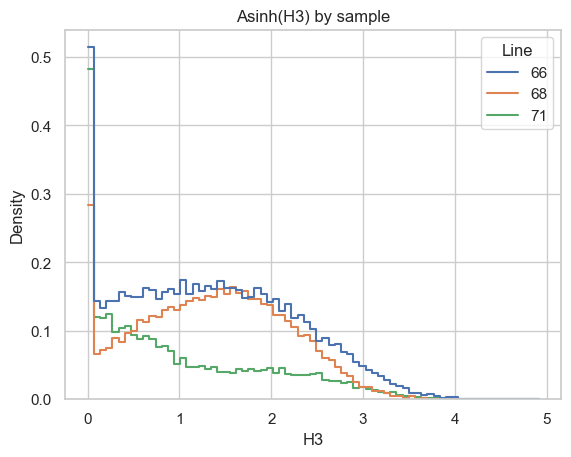

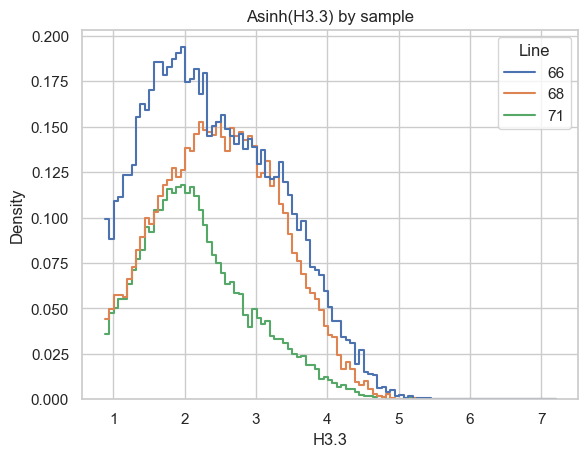

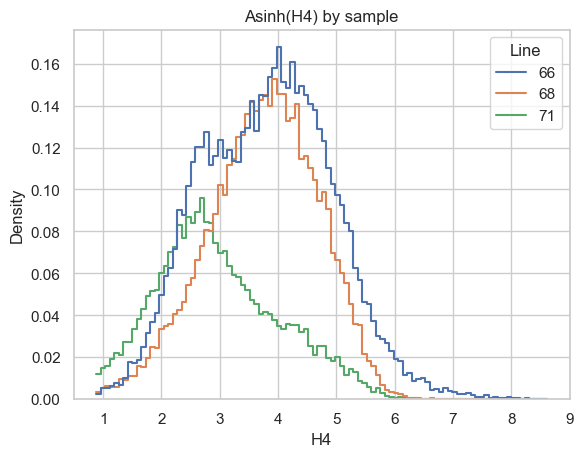

In [15]:
# Step 2: arcsinh transform with cofactor 5
scFac = 5
DF_asinh = DF_gated.copy()
DF_asinh[marker_cols] = np.arcsinh(DF_asinh[marker_cols] / scFac)
DF_asinh['Line'] = DF_asinh['sample'].astype(str)

# Quick QC on control markers after arcsinh
for mk in ['H3', 'H3.3', 'H4']:
    sns.histplot(data=DF_asinh, x=mk, hue='Line', **hKWD)
    plt.title(f'Asinh({mk}) by sample')
    plt.show()


In [16]:
# Marker sets for correction (as in CyTOF7-NewNorm)
control_markers = ['H3.3',  'H4']

try:
    NamesAll, EpiCols, NormMRK, CellIden, CellCyle = GetMarkers(sorted(marker_cols))
    markers_to_correct = [m for m in NormMRK if m in marker_cols and m not in control_markers]
    print('Using GetMarkers()')
except Exception as exc:
    print(f'GetMarkers failed, using fallback marker list. Reason: {exc}')
    NamesAll = sorted(marker_cols)
    markers_to_correct = [m for m in marker_cols if m not in control_markers]

print('markers_to_correct:', len(markers_to_correct))


Using GetMarkers()
markers_to_correct: 33


<Axes: xlabel='CD45', ylabel='Count'>

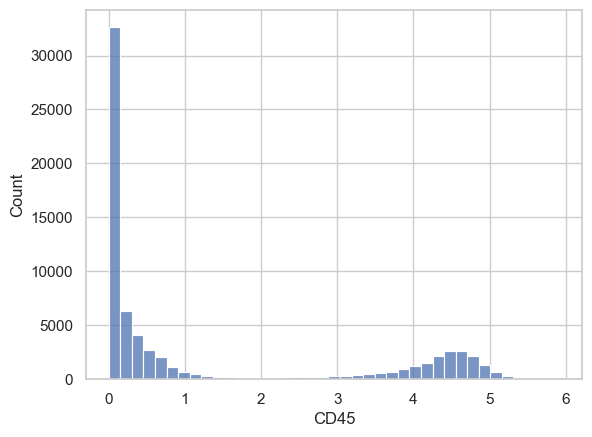

In [17]:
sns.histplot(DF_asinh.CD45)

In [18]:
M=DF_asinh.CD45<2
DF_asinh=DF_asinh[M]

Normalizing separately for samples: ['66', '68', '71']
[CyTOF-transform] Computed PC1 technical factor for 'global' (explained var PC1 = 0.823)
[CyTOF-transform] Computed PC1 technical factor for 'global' (explained var PC1 = 0.857)
[CyTOF-transform] Computed PC1 technical factor for 'global' (explained var PC1 = 0.813)


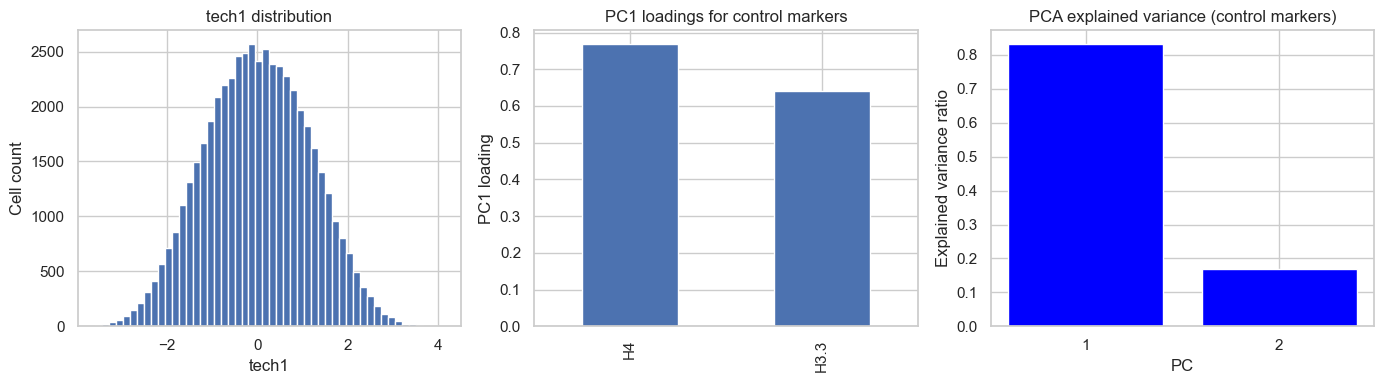

/Users/ronguy/Dropbox/Work/CyTOF/Code/cytof_transform.py:724: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


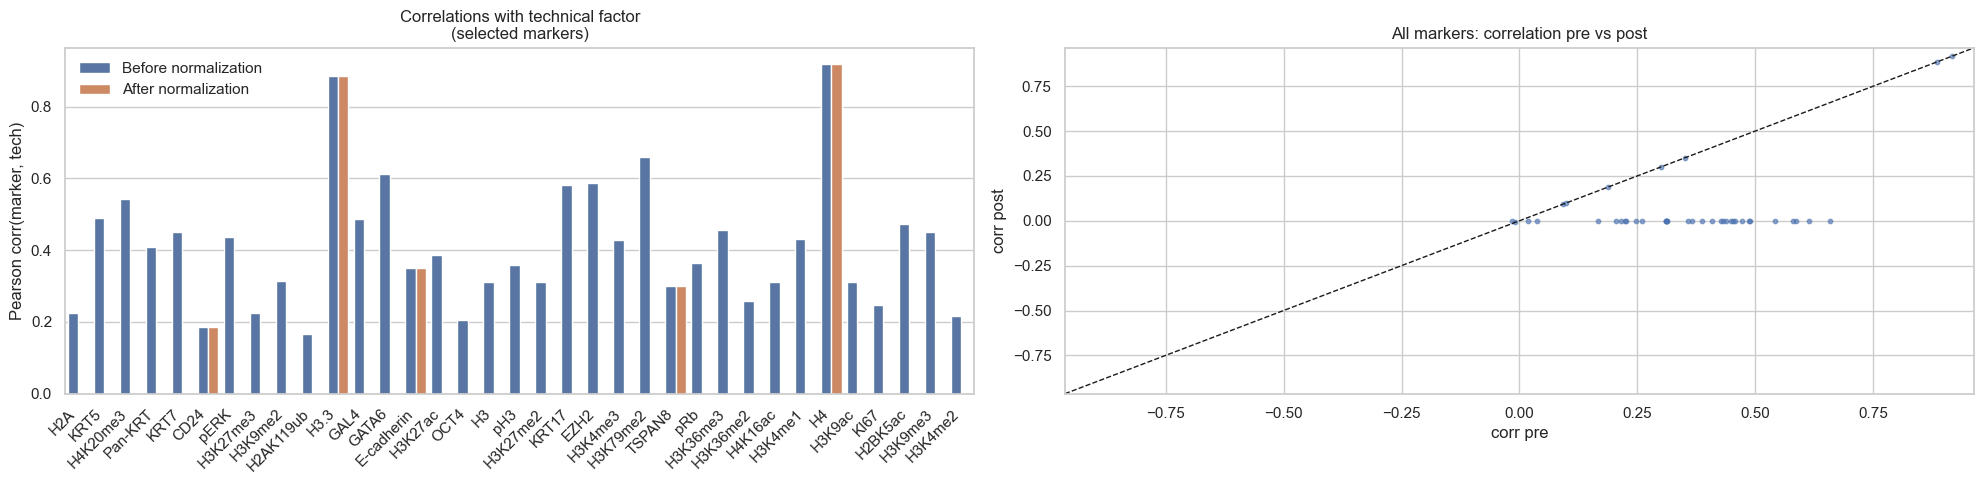

In [19]:
# Step 3: technical-factor correction (separately per sample)
samples = sorted(DF_asinh['Line'].astype(str).unique().tolist())
print('Normalizing separately for samples:', samples)

corr_parts = []
tech_parts = []

for smp in samples:
    mask = DF_asinh['Line'].astype(str) == smp
    asinh_data_s = DF_asinh.loc[mask, marker_cols].copy()

    cfg_s = CytofTransformConfig(
        control_markers=control_markers,
        markers_to_correct=markers_to_correct,
        use_compartments=False,
        n_pcs_for_T=1,
        anchor_to_median=True,
        zscore=False,
        line_col=None,
    )

    result_s = cytof_transform_global(asinh_data_s, cfg_s)
    corr_parts.append(result_s.corrected)
    tech_parts.append(pd.Series(result_s.tech_factor.values, index=asinh_data_s.index, name='tech1'))

asinh_corr_global = pd.concat(corr_parts, axis=0).loc[DF_asinh.index]
tech1_series = pd.concat(tech_parts, axis=0).loc[DF_asinh.index]

# Optional QC: pooled overview
_tech1, _loadings, _ev = plot_tech_factor_qc(
    asinh_data=DF_asinh[marker_cols],
    control_markers=control_markers,
    tech_factor=tech1_series,
    tech_name='tech1',
)

_ = plot_marker_correlations_qc(
    asinh_pre=DF_asinh[marker_cols],
    asinh_post=asinh_corr_global[marker_cols],
    tech_factor=tech1_series,
    top_n=35,
)


In [20]:
# Step 4: build AnnData and save h5ad in ../data/
obs = DF_asinh[metadata_cols + ['Line']].copy()
obs['tech1'] = tech1_series.values

if 'cell_id' in obs.columns:
    obs.index = obs['cell_id'].astype(str)
    if obs.index.has_duplicates:
        obs.index = pd.Index([f'{idx}_{i}' for i, idx in enumerate(obs.index)], name='cell_id')

var = pd.DataFrame(index=marker_cols)
X_corr = asinh_corr_global[marker_cols].to_numpy(dtype=np.float32)

adata = ad.AnnData(X=X_corr, obs=obs, var=var)
adata.layers['asinh_uncorrected'] = DF_asinh[marker_cols].to_numpy(dtype=np.float32)

OUTPUT_H5AD.parent.mkdir(parents=True, exist_ok=True)
adata.write_h5ad(OUTPUT_H5AD)

print('Saved:', OUTPUT_H5AD.resolve())
print('adata:', adata.shape)


Saved: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/data/PDAC_normalized.h5ad
adata: (51136, 41)


In [21]:
# Quick reload check
adata_check = ad.read_h5ad(OUTPUT_H5AD)
print('Reloaded:', adata_check.shape)
adata_check.obs[['sample', 'Treatment']]

Reloaded: (51136, 41)


,sample,Treatment
cell_id,,
66__num_000001,66,Untreated
66__num_000002,66,Untreated
66__num_000004,66,Untreated
66__num_000005,66,Untreated
66__num_000007,66,Untreated
...,...,...
71__num_015856,71,Treated
71__num_015859,71,Treated
71__num_015861,71,Treated


In [22]:
import scanpy as sc

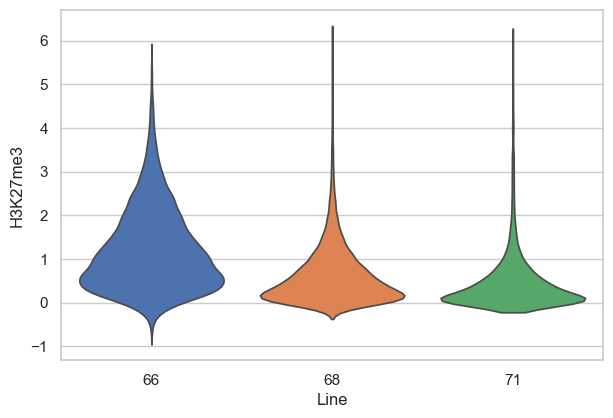

In [23]:
sc.pl.violin(adata_check,keys='H3K27me3',groupby='Line',stripplot=False,saturation=1)

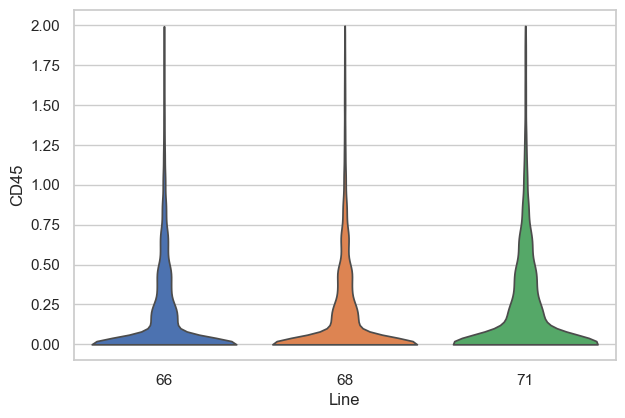

In [24]:
sc.pl.violin(adata_check,keys='CD45',groupby='Line',stripplot=False,saturation=1)